# Import

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

# Extra Functions

In [232]:
def lorentzian_profile(x, gamma):
    return gamma / (np.pi * (x**2 + gamma**2))

def gaussian_profile(x, sigma):
    return (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-(x**2)/(2*sigma**2))

def voigt_profile_single(x, A1, centre1, gamma1, sigma1):
    return(A1*voigt_profile(x - centre1, sigma1, gamma1))

def voigt_model_double(x, A1, center1, gamma1, sigma1,
                       A2, delta, gamma2, sigma2, offset):

    return (
        A1 * voigt_profile(x - center1, sigma1, gamma1) +
        A2 * voigt_profile(x - (center1 + delta), sigma2, gamma2) +
        offset
    )

def lorentzian_model_double(x, A1, center1, gamma1,
                            A2, delta, gamma2, offset):

    return (
        A1 * lorentzian_profile(x - center1, gamma1) +
        A2 * lorentzian_profile(x - (center1 + delta), gamma2) +
        offset
    )

def gaussian_model_double(x, A1, center1, sigma1,
                          A2, delta, sigma2, offset):

    return (
        A1 * gaussian_profile(x - center1, sigma1) +
        A2 * gaussian_profile(x - (center1 + delta), sigma2) +
        offset
    )



def reduced_chi_squared_calc(model, model_params, xdata, ydata, yerror):
    dof = len(xdata)-len(model_params)
    theoretical = model(xdata,*model_params)
    chi2 = np.sum((theoretical - ydata)**2/(yerror**2))
    rchi2 = chi2/dof
    return rchi2

def residual_calculator(xdata, ydata, yerr, model, model_params):
    fit = model(xdata, *model_params)
    residual = ydata - fit
    norm_residual = residual/yerr
    return  norm_residual

# Setup and calculations

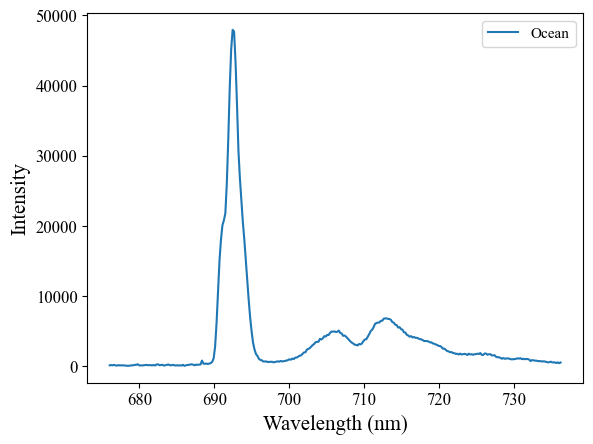

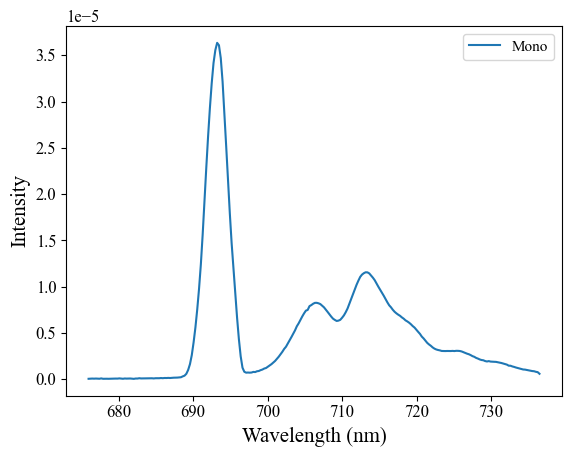

In [86]:
# Extraction

ocean_file = "Ocean_Opt_Data.xlsx"
df_ocean = pd.read_excel(ocean_file)

x_ocean = df_ocean["W_77"].to_numpy()
y_ocean = df_ocean["I_77"].to_numpy()

mono_file = "mono_77_9830_Data.csv"
df_mono = pd.read_csv(mono_file)

x_mono = df_mono["x"].to_numpy()
y_mono = df_mono["y"].to_numpy()
y_err_mono = df_mono["yerr"].to_numpy()

x_mono = np.flip(x_mono)
y_mono = np.flip(y_mono)
y_err_mono = np.flip(y_err_mono)

ind_min = np.argmin(np.abs(x_ocean - x_mono[0]))
ind_max = np.argmin(np.abs(x_ocean - x_mono[-1]))

x_ocean = x_ocean[ind_min:ind_max]
y_ocean = y_ocean[ind_min:ind_max]


plt.figure(1)
plt.plot(x_ocean, y_ocean, label="Ocean")
plt.legend()
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.show()

plt.figure(1)
plt.plot(x_mono, y_mono, label="Mono")
plt.legend()
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.show()

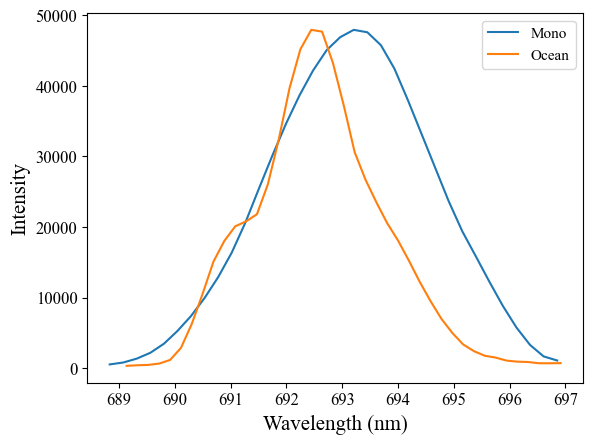

In [162]:
# masking

mask_min_ocean = 689.1
mask_max_ocean = 697

mask_min_mono = 688.7
mask_max_mono = 697

mask_ocean = (x_ocean >= mask_min_ocean) & (x_ocean <= mask_max_ocean)
mask_mono = (x_mono >= mask_min_mono) & (x_mono <= mask_max_mono)

x_ocean_masked = x_ocean[mask_ocean]
y_ocean_masked = y_ocean[mask_ocean]

x_mono_masked = x_mono[mask_mono]
y_mono_masked = y_mono[mask_mono]
y_err_mono_masked = y_err_mono[mask_mono]

normalisation_scalefactor = (np.max(y_ocean_masked)/np.max(y_mono_masked))

y_mono_masked = y_mono_masked*normalisation_scalefactor
y_err_mono_masked = y_err_mono_masked*normalisation_scalefactor

plt.figure()

plt.plot(x_mono_masked, y_mono_masked, label="Mono")
plt.plot(x_ocean_masked, y_ocean_masked, label="Ocean")
plt.legend()
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")

plt.show()

In [210]:
#fake errorbars for ocean, need to recollect this:
y_err_ocean = 0.01* y_ocean_masked

In [211]:
# Fitting to Ocean

############
# Lorentzian
############


p0_ocean_lorentzian = [0.5*np.max(y_ocean_masked), x_ocean_masked[np.argmax(y_ocean_masked)], 0.3, 0.5*np.max(y_ocean_masked), -1.4, 0.3, np.min(y_ocean_masked)]
bounds_ocean_lorentzian = [
    [0,690, 0, 0.03*np.max(y_ocean_masked), -2, 0, 0], #lower
    [np.max(y_ocean_masked), 693, np.inf, np.max(y_ocean_masked), -0.5, np.inf, np.inf]] #upper

pop_ocean_lorentzian , cov_ocean_lorentzian = curve_fit(lorentzian_model_double,
                                    xdata= x_ocean_masked,
                                    ydata = y_ocean_masked,
                                    p0 = p0_ocean_lorentzian,
                                    bounds = bounds_ocean_lorentzian)

In [212]:
############
# Gaussian
############


p0_ocean_gaussian = [0.85*np.max(y_ocean_masked), x_ocean_masked[np.argmax(y_ocean_masked)], 0.3, 0.15*np.max(y_ocean_masked), -1.4, 0.3, np.min(y_ocean_masked)]
bounds_ocean_gaussian = [
    [0,692, 0, 0, -2, 0, 0], #lower
    [np.inf, 694, np.inf, np.inf, -0.5, np.inf, np.inf]] #upper

pop_ocean_gaussian , cov_ocean_gaussian = curve_fit(gaussian_model_double,
                                    xdata= x_ocean_masked,
                                    ydata = y_ocean_masked,
                                    p0 = p0_ocean_gaussian,
                                    bounds = bounds_ocean_gaussian)

In [213]:
############
# Voigt
############


p0_ocean_voigt = [0.5*np.max(y_ocean_masked), x_ocean_masked[np.argmax(y_ocean_masked)], 0.3, 0.3, 0.5*np.max(y_ocean_masked), -1.4, 0.3, 0.3, np.min(y_ocean_masked)]
bounds_ocean_voigt = [
    [0,690, 0, 0, 0.03*np.max(y_ocean_masked), -2, 0, 0, 0], #lower
    [np.inf, 694, np.inf, np.inf, np.inf, -0.5, np.inf, np.inf, np.inf]] #upper

pop_ocean_voigt , cov_ocean_voigt = curve_fit(voigt_model_double,
                                    xdata= x_ocean_masked,
                                    ydata = y_ocean_masked,
                                    p0 = p0_ocean_voigt,
                                    bounds = bounds_ocean_voigt,
                                    maxfev=30000)

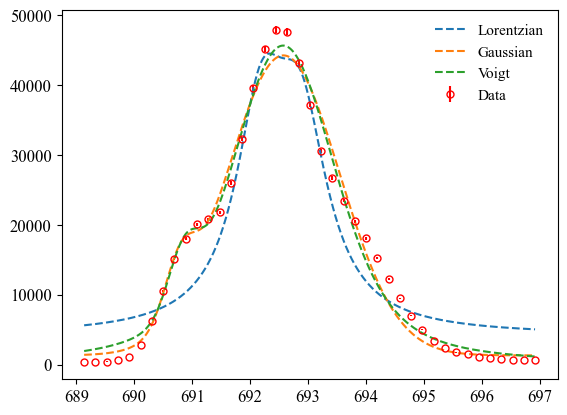

In [214]:
pops_ocean = [pop_ocean_lorentzian, pop_ocean_gaussian, pop_ocean_voigt]
models = [lorentzian_model_double, gaussian_model_double, voigt_model_double]
labels = ['Lorentzian', 'Gaussian', 'Voigt']

x_fit_ocean = np.linspace(x_ocean_masked.min(), x_ocean_masked.max(), 2000)
x_fit_mono  = np.linspace(x_mono_masked.min(), x_mono_masked.max(), 2000)

plt.figure(1)

plt.errorbar(x_ocean_masked, y_ocean_masked, yerr = y_err_ocean,
             color ='red', marker='o', linestyle = "none", markersize = 5, markerfacecolor = "none",
             label='Data')

for pop, model, label in zip(pops_ocean, models, labels):
    plt.plot(x_fit_ocean, model(x_fit_ocean, *pop), label = label,
             linestyle = "--")

plt.legend(loc='best',
           frameon = False)
plt.show()

In [215]:
# Fitting to mono

############
# Lorentzian
############


p0_mono_lorentzian = [0.85*np.max(y_mono_masked), x_mono_masked[np.argmax(y_mono_masked)], 0.3, 0.15*np.max(y_mono_masked), -1.4, 0.3, np.min(y_mono_masked)]
bounds_mono_lorentzian = [
    [0,690, 0, 0.03*np.max(y_mono_masked), -2, 0, 0], #lower
    [np.inf, 694, np.inf, np.inf, -0.5, np.inf, np.inf]] #upper

pop_mono_lorentzian , cov_mono_lorentzian = curve_fit(lorentzian_model_double,
                                    xdata= x_mono_masked,
                                    ydata = y_mono_masked,
                                    sigma = y_err_mono_masked,
                                    absolute_sigma = True,
                                    p0 = p0_mono_lorentzian,
                                    bounds = bounds_mono_lorentzian)

rchi2_mono_lorentzian = reduced_chi_squared_calc(lorentzian_model_double, pop_mono_lorentzian, x_mono_masked, y_mono_masked, y_err_mono_masked)

In [216]:
############
# Gaussian
############


p0_mono_gaussian = [0.85*np.max(y_mono_masked), x_mono_masked[np.argmax(y_mono_masked)], 0.3, 0.15*np.max(y_mono_masked), -1.4, 0.3, np.min(y_mono_masked)]
bounds_mono_gaussian = [
    [0,690, 0, 0.03*np.max(y_mono_masked), -2, 0, 0], #lower
    [np.inf, 694, np.inf, np.inf, -0.5, np.inf, np.inf]] #upper

pop_mono_gaussian , cov_mono_gaussian = curve_fit(gaussian_model_double,
                                    xdata= x_mono_masked,
                                    ydata = y_mono_masked,
                                    sigma = y_err_mono_masked,
                                    absolute_sigma = True,
                                    p0 = p0_mono_gaussian,
                                    bounds = bounds_mono_gaussian)

rchi2_mono_gaussian = reduced_chi_squared_calc(gaussian_model_double, pop_mono_gaussian, x_mono_masked, y_mono_masked, y_err_mono_masked)

In [217]:
############
# Voigt
############


p0_mono_voigt = [0.85*np.max(y_mono_masked), x_mono_masked[np.argmax(y_mono_masked)], 0.3, 0.3, 0.15*np.max(y_mono_masked), -1.4, 0.3, 0.3, np.min(y_mono_masked)]
bounds_mono_voigt = [
    [0,690, 0, 0, 0.03*np.max(y_mono_masked), -2, 0, 0, 0], #lower
    [np.inf, 694, np.inf, np.inf, np.inf, -0.5, np.inf, np.inf, np.inf]] #upper

pop_mono_voigt , cov_mono_voigt = curve_fit(voigt_model_double,
                                    xdata= x_mono_masked,
                                    ydata = y_mono_masked,
                                    sigma = y_err_mono_masked,
                                    absolute_sigma = True,
                                    p0 = p0_mono_voigt,
                                    bounds = bounds_mono_voigt)

rchi2_mono_voigt = reduced_chi_squared_calc(voigt_model_double, pop_mono_voigt, x_mono_masked, y_mono_masked, y_err_mono_masked)

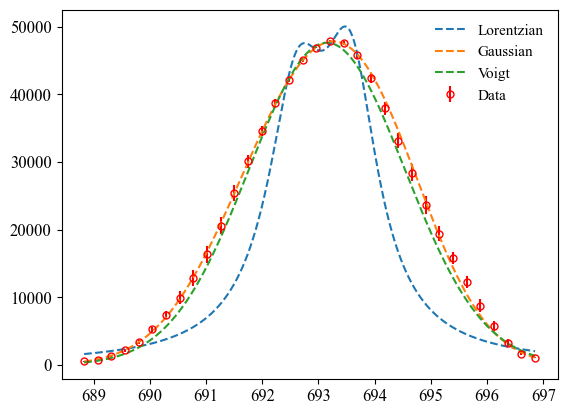

In [218]:
pops_mono = [pop_mono_lorentzian, pop_mono_gaussian, pop_mono_voigt]
models = [lorentzian_model_double, gaussian_model_double, voigt_model_double]
labels = ['Lorentzian', 'Gaussian', 'Voigt']

x_fit = np.linspace(x_mono_masked.min(), x_mono_masked.max(), 2000)

plt.figure(1)

plt.errorbar(x_mono_masked, y_mono_masked, yerr = y_err_mono_masked,
             color ='red', marker='o', linestyle = "none", markersize = 5, markerfacecolor = "none",
             label='Data')

for pop, model, label in zip(pops_mono, models, labels):
    plt.plot(x_fit_mono, model(x_fit_mono, *pop), label = label,
             linestyle = "--")

plt.legend(loc='best',
           frameon = False)
plt.show()

# Main Plot Prep

In [237]:
# prep
red_cb = "#e41a1c"
blue_cb = "#377eb8"
green_cb = "#4daf4a"

fit_colours = [red_cb, blue_cb, green_cb]
marker = "o"

plt.rcParams.update({
    "font.size": 14,        # default text size
    "axes.titlesize": 16,   # title size
    "axes.labelsize": 15,   # axis labels
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

plt.rcParams.update({
    "font.family": "Times New Roman",  # Use Times New Roman for all text
    "mathtext.fontset": "custom",      # Use custom font for math
    "mathtext.rm": "Times New Roman",  # Roman font in math
    "mathtext.it": "Times New Roman:italic",  # Italic font in math
    "mathtext.bf": "Times New Roman:bold",    # Bold font in math
    "text.usetex": False
})

laptop_savepath_Peak_Plots = r"\peak_plot.png"
pc_savepath_Peak_Plots = r"C:\Users\User\Documents\Durham Work\Year 3\Advanced_Lab\Report\Figures\peak_plot.png"

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib.patches import ConnectionPatch

#residuals
residual_ocean_lorentzian = residual_calculator(x_ocean_masked, y_ocean_masked, y_err_ocean, lorentzian_model_double, pop_ocean_lorentzian)
residual_ocean_gaussian = residual_calculator(x_ocean_masked, y_ocean_masked, y_err_ocean, gaussian_model_double, pop_ocean_gaussian)
residual_ocean_voigt = residual_calculator(x_ocean_masked, y_ocean_masked, y_err_ocean, voigt_model_double, pop_ocean_voigt)

residual_mono_lorentzian = residual_calculator(x_mono_masked, y_mono_masked, y_err_mono_masked, lorentzian_model_double, pop_mono_lorentzian)
residual_mono_gaussian = residual_calculator(x_mono_masked, y_mono_masked, y_err_mono_masked, gaussian_model_double, pop_mono_gaussian)
residual_mono_voigt = residual_calculator(x_mono_masked, y_mono_masked, y_err_mono_masked, voigt_model_double, pop_mono_voigt)

lorentzian_residuals = [residual_ocean_lorentzian, residual_mono_lorentzian]
gaussian_residuals = [residual_ocean_gaussian, residual_mono_gaussian]
voigt_residuals = [residual_ocean_voigt, residual_mono_voigt]

x_data_set = [x_ocean_masked, x_mono_masked]
y_data_set = [y_ocean_masked, y_mono_masked]
y_err_set = [y_err_ocean, y_err_mono_masked]

pops_lorentzian = [pop_ocean_lorentzian, pop_mono_lorentzian]
pops_gaussian = [pop_ocean_gaussian, pop_mono_gaussian]
pops_voigt = [pop_ocean_voigt, pop_mono_voigt]

angstrom_scalefactor = 10

# Main Plot Lorentzian

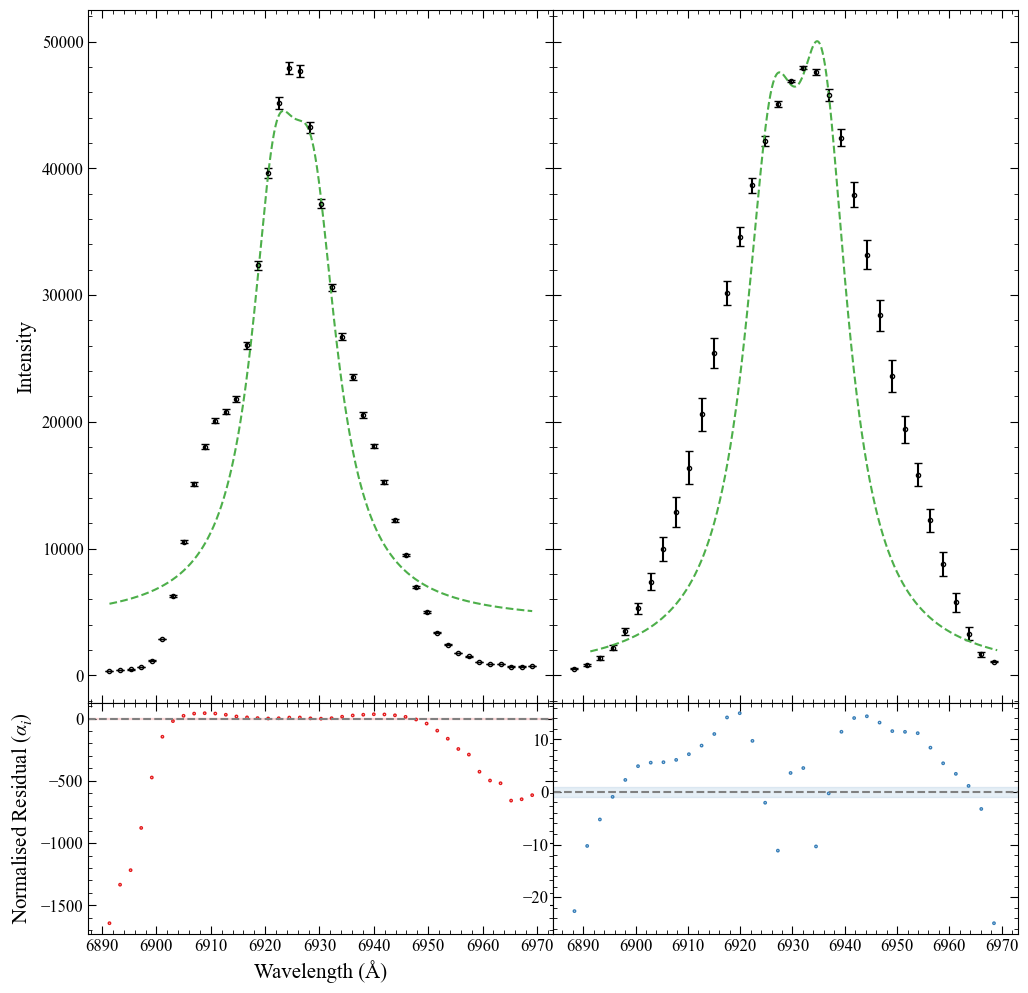

In [220]:
# Lorentzian Plot

fig = plt.figure(figsize = (12,12))

gs = fig.add_gridspec(
    2, 2,
    width_ratios = [1, 1],
    height_ratios = [3, 1],
    wspace = 0,
    hspace = 0
)

ax_main_ocean = fig.add_subplot(gs[0, 0])
ax_res1_ocean = fig.add_subplot(gs[1, 0], sharex = ax_main_ocean)

ax_main_mono = fig.add_subplot(gs[0, 1], sharey=ax_main_ocean)
ax_res1_mono = fig.add_subplot(gs[1, 1], sharex = ax_main_mono)

#########
# Styling
#########

for ax in [ax_main_ocean, ax_res1_ocean, ax_main_mono, ax_res1_mono]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)



for ax in [ax_main_ocean, ax_res1_ocean, ax_main_mono, ax_res1_mono]:
    for label in ax.get_xticklabels()+ ax.get_yticklabels():
        label.set_bbox(dict(
            facecolor="white",
            edgecolor="none",
            pad=1.0
        ))

for ax in [ax_main_ocean, ax_main_mono]:
    ax.tick_params(axis="x", labelbottom=False)

ax_main_mono.tick_params(axis = "y", labelleft=False)

###########
# Main Plot
###########

for ax, xdata, ydata, yerror in zip([ax_main_ocean, ax_main_mono], x_data_set, y_data_set, y_err_set):
    ax.errorbar(xdata*angstrom_scalefactor, ydata, yerr = yerror,
                marker = marker, capsize = 3, markersize = 3, markerfacecolor = "none", linestyle = "none", color = "black")

for ax, pop in zip([ax_main_ocean, ax_main_mono], pops_lorentzian):
    ax.plot(x_fit_ocean*angstrom_scalefactor, lorentzian_model_double(x_fit_ocean, *pop),
                       color = green_cb, linestyle = "--")

ax_main_ocean.set_ylabel("Intensity")

###########
# Residuals
###########

for ax, xdata, residual, colour in zip([ax_res1_ocean, ax_res1_mono], x_data_set, lorentzian_residuals, fit_colours):
    ax.scatter(xdata*angstrom_scalefactor, residual,
               color = colour, marker = marker, s = 3, facecolors = "none")
    ax.axhspan(-1,1, color = colour, alpha = 0.12)
    ax.axhline(0, color = "grey", linestyle = "--")

ax_res1_ocean.set_xlabel("Wavelength (Å)")
ax_res1_ocean.set_ylabel(rf"Normalised Residuals ($\alpha_i$)")

plt.savefig(pc_savepath_Peak_Plots,
            dpi = 600,
            bbox_inches = 'tight')

plt.show()

# Main Plot Gaussian

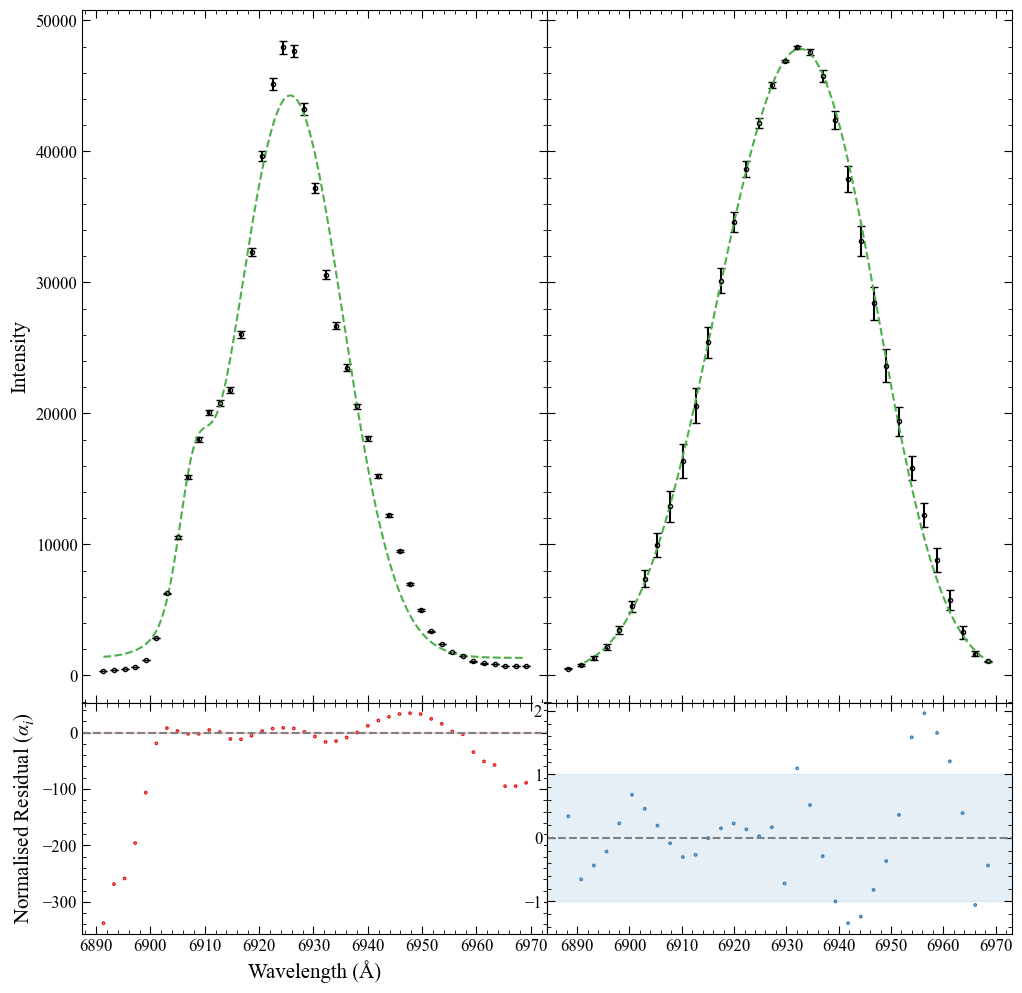

In [223]:
# Gaussian Plot

fig = plt.figure(figsize=(12, 12))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1, 1],
    height_ratios=[3, 1],
    wspace=0,
    hspace=0
)

ax_main_ocean = fig.add_subplot(gs[0, 0])
ax_res1_ocean = fig.add_subplot(gs[1, 0], sharex=ax_main_ocean)

ax_main_mono = fig.add_subplot(gs[0, 1], sharey=ax_main_ocean)
ax_res1_mono = fig.add_subplot(gs[1, 1], sharex=ax_main_mono)

#########
# Styling
#########

for ax in [ax_main_ocean, ax_res1_ocean, ax_main_mono, ax_res1_mono]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)

for ax in [ax_main_ocean, ax_res1_ocean, ax_main_mono, ax_res1_mono]:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_bbox(dict(
            facecolor="white",
            edgecolor="none",
            pad=1.0
        ))

for ax in [ax_main_ocean, ax_main_mono]:
    ax.tick_params(axis="x", labelbottom=False)

ax_main_mono.tick_params(axis="y", labelleft=False)

###########
# Main Plot
###########

for ax, xdata, ydata, yerror in zip([ax_main_ocean, ax_main_mono], x_data_set, y_data_set, y_err_set):
    ax.errorbar(xdata * angstrom_scalefactor, ydata, yerr=yerror,
                marker=marker, capsize=3, markersize=3, markerfacecolor="none", linestyle="none", color="black")

for ax, pop in zip([ax_main_ocean, ax_main_mono], pops_gaussian):
    ax.plot(x_fit_ocean * angstrom_scalefactor, gaussian_model_double(x_fit_ocean, *pop),
            color=green_cb, linestyle="--")

ax_main_ocean.set_ylabel("Intensity")

###########
# Residuals
###########

for ax, xdata, residual, colour in zip([ax_res1_ocean, ax_res1_mono], x_data_set, gaussian_residuals, fit_colours):
    ax.scatter(xdata * angstrom_scalefactor, residual,
               color=colour, marker=marker, s=3, facecolors="none")
    ax.axhspan(-1, 1, color=colour, alpha=0.12)
    ax.axhline(0, color="grey", linestyle="--")

ax_res1_ocean.set_xlabel("Wavelength (Å)")
ax_res1_ocean.set_ylabel(rf"Normalised Residuals ($\alpha_i$)")

plt.savefig(pc_savepath_Peak_Plots,
            dpi=600,
            bbox_inches='tight')

plt.show()

# Main Plot Voigt

In [242]:
R1_ocean_voigt = voigt_profile_single(
    x_fit_ocean,
    pop_ocean_voigt[0], pop_ocean_voigt[1], pop_ocean_voigt[2], pop_ocean_voigt[3]
)

R2_ocean_voigt = voigt_profile_single(
    x_fit_ocean,
    pop_ocean_voigt[4], pop_ocean_voigt[1] + pop_ocean_voigt[5], pop_ocean_voigt[6], pop_ocean_voigt[7]
)

R1_mono_voigt = voigt_profile_single(
    x_fit_mono,
    pop_mono_voigt[0], pop_mono_voigt[1], pop_mono_voigt[2], pop_mono_voigt[3]
)

R2_mono_voigt = voigt_profile_single(
    x_fit_mono,
    pop_mono_voigt[4], pop_mono_voigt[1] + pop_mono_voigt[5], pop_mono_voigt[6], pop_mono_voigt[7]
)

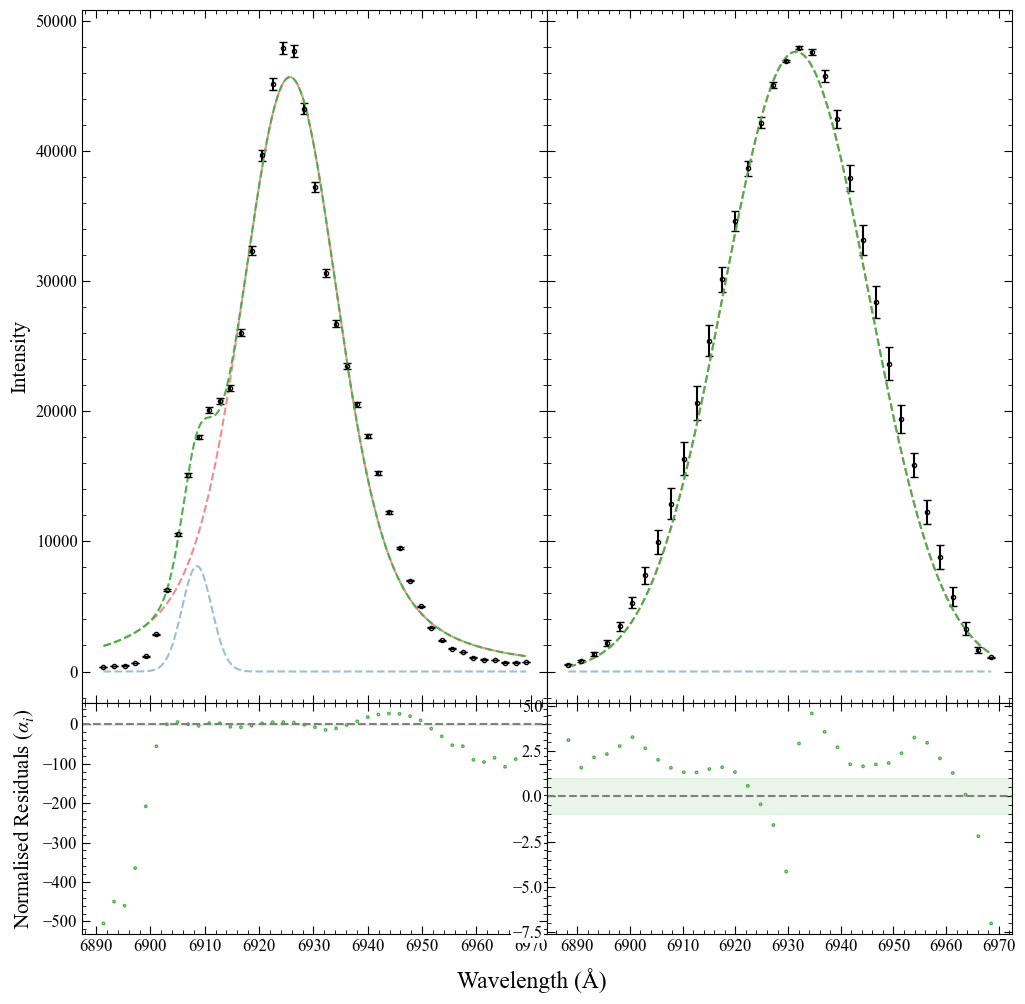

In [241]:
# Voigt Plot

fig = plt.figure(figsize=(12, 12))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1, 1],
    height_ratios=[3, 1],
    wspace=0,
    hspace=0
)

ax_main_ocean = fig.add_subplot(gs[0, 0])
ax_res1_ocean = fig.add_subplot(gs[1, 0], sharex=ax_main_ocean)

ax_main_mono = fig.add_subplot(gs[0, 1], sharey=ax_main_ocean)
ax_res1_mono = fig.add_subplot(gs[1, 1], sharex=ax_main_mono)

#########
# Styling
#########

for ax in [ax_main_ocean, ax_res1_ocean, ax_main_mono, ax_res1_mono]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)

for ax in [ax_main_ocean, ax_res1_ocean, ax_main_mono, ax_res1_mono]:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_bbox(dict(
            facecolor="white",
            edgecolor="none",
            pad=1.0
        ))

for ax in [ax_main_ocean, ax_main_mono]:
    ax.tick_params(axis="x", labelbottom=False)

ax_main_mono.tick_params(axis="y", labelleft=False)

###########
# Main Plot
###########

for ax, xdata, ydata, yerror in zip([ax_main_ocean, ax_main_mono], x_data_set, y_data_set, y_err_set):
    ax.errorbar(xdata * angstrom_scalefactor, ydata, yerr=yerror,
                marker=marker, capsize=3, markersize=3, markerfacecolor="none", linestyle="none", color="black")

# Ocean
ax_main_ocean.plot(x_fit_ocean * angstrom_scalefactor,
                   voigt_model_double(x_fit_ocean, *pops_voigt[0]),
                   color=green_cb, linestyle="--")

ax_main_ocean.plot(x_fit_ocean*angstrom_scalefactor, R1_ocean_voigt,
                   color=red_cb, linestyle="--", alpha = 0.5, zorder=-1)

ax_main_ocean.plot(x_fit_ocean*angstrom_scalefactor, R2_ocean_voigt,
                   color=blue_cb, linestyle="--", alpha = 0.5, zorder=-1)


# Mono
ax_main_mono.plot(x_fit_mono * angstrom_scalefactor,
                  voigt_model_double(x_fit_mono, *pops_voigt[1]),
                  color=green_cb, linestyle="--")

ax_main_mono.plot(x_fit_mono*angstrom_scalefactor, R1_mono_voigt,
                   color=red_cb, linestyle="--", alpha = 0.5, zorder=-1)

ax_main_mono.plot(x_fit_mono*angstrom_scalefactor, R2_mono_voigt,
                   color=blue_cb, linestyle="--", alpha = 0.5, zorder=-1)

ax_main_ocean.set_ylabel("Intensity")

###########
# Residuals
###########

for ax, xdata, residual in zip([ax_res1_ocean, ax_res1_mono], x_data_set, voigt_residuals):
    ax.scatter(xdata * angstrom_scalefactor, residual,
               color=green_cb, marker=marker, s=3, facecolors="none")
    ax.axhspan(-1, 1, color=green_cb, alpha=0.12)
    ax.axhline(0, color="grey", linestyle="--")

ax_res1_ocean.set_ylabel(rf"Normalised Residuals ($\alpha_i$)")

fig.supxlabel("Wavelength (Å)", y = 0.06)

plt.savefig(pc_savepath_Peak_Plots,
            dpi=600,
            bbox_inches='tight')

plt.show()